Längenmessung


In [29]:
import numpy as np
import uncertainties as unc
import uncertainties.unumpy as unp

In [ ]:
err_scale = np.full(3, 0.1)

x_a = unp.uarray([98.5, 98.4, 98.5], err_scale)
x_o = unp.uarray([9.8, 9.9, 10], err_scale)
x_u = unp.uarray([7.6, 7.6, 7.55], err_scale)


[98.5+/-0.1 98.4+/-0.1 98.5+/-0.1]


In [ ]:
L = x_a - 0.5*(x_o-x_u)
print(L)


sigma_stat = np.std(unp.nominal_values(L))/np.sqrt(len(L))
print(sigma_stat)

l_final = np.sqrt(sigma_stat**2 + unp.std_devs(L)**2/3)
print(l_final)

l_final/unp.nominal_values(L)

[97.4+/-0.12247448713915891 97.25+/-0.12247448713915891
 97.275+/-0.12247448713915891]
[97.4   97.25  97.275]
0.037883838047183906
[0.08021961 0.08021961 0.08021961]


array([0.00082361, 0.00082488, 0.00082467])

plot

Text(0.5, 1.0, 'Falk schöner plot')

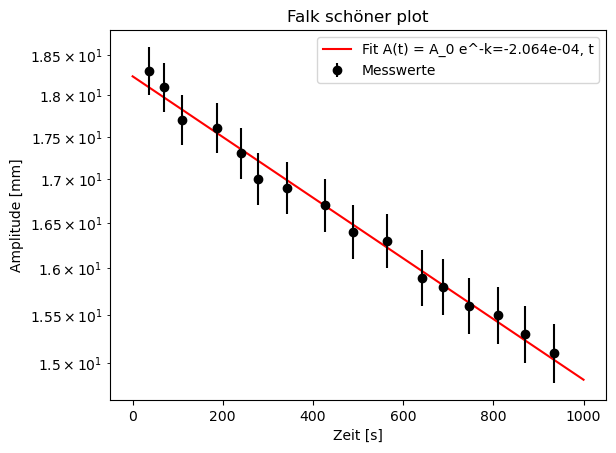

In [76]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


time = np.array([36.98, 70.1, 108.98, 186.18, 240.00, 278.99, 343.08, 426.48, 489.09, 564.50, 642.70, 687.58, 746.2, 810.4, 870.4, 933.49])

ampltude = np.array([18.30, 18.1, 17.7, 17.6, 17.3, 17.0, 16.9, 16.7, 16.4, 16.3, 15.9, 15.8, 15.6, 15.5, 15.3, 15.1])
err_a = 0.3

curve = lambda t, a, b: a*np.exp(-b*t)
popt, pcov = curve_fit(curve, time, ampltude, p0=(20, 0.001), sigma=err_a)

k = popt[1]

x = np.linspace(0, 1000, 100)
plt.plot(x, curve(x, *popt), '-', label=f'Fit A(t) = A_0 e^{-k=:.3e}, t', color='red')

plt.errorbar(time, ampltude, yerr=err_a, fmt='o', label=f'Messwerte', color='black')
plt.yscale('log')

plt.xlabel('Zeit [s]')
plt.ylabel('Amplitude [mm]')
plt.legend()
plt.title('Falk schöner plot')
